In [1]:
import pandas as pd
import sys
from pathlib import Path
root_path = Path().resolve().parent.parent

sys.path.append(str(root_path))

from utils.eda import summary_stats, missing_report, outlier_report, class_balance, correlation_matrix
from utils.visualization import plot_distributions, plot_boxplot, plot_class_balance

In [2]:
df = pd.read_csv(root_path / "telco customer churn" / 'data' / 'WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
summary_stats(df)

SHAPE        : 7043 rows × 21 columns

── DTYPES ──
                    dtype  nunique            sample
customerID         object     7043        7590-VHVEG
gender             object        2            Female
SeniorCitizen       int64        2                 0
Partner            object        2               Yes
Dependents         object        2                No
tenure              int64       73                 1
PhoneService       object        2                No
MultipleLines      object        3  No phone service
InternetService    object        3               DSL
OnlineSecurity     object        3                No
OnlineBackup       object        3               Yes
DeviceProtection   object        3                No
TechSupport        object        3                No
StreamingTV        object        3                No
StreamingMovies    object        3                No
Contract           object        3    Month-to-month
PaperlessBilling   object        2             

In [4]:
missing_report(df)

MISSING VALUE REPORT  (total kolom: 21)
✓ Tidak ada missing values.


In [5]:
print(f"Jumlah data duplikat: {df.duplicated().sum()}")

Jumlah data duplikat: 0


In [6]:
df.drop(columns="customerID", inplace=True)

In [7]:
fitur_numeric = df.select_dtypes(include='number').columns.tolist()
fitur_category = df.select_dtypes(include='object').columns.tolist()

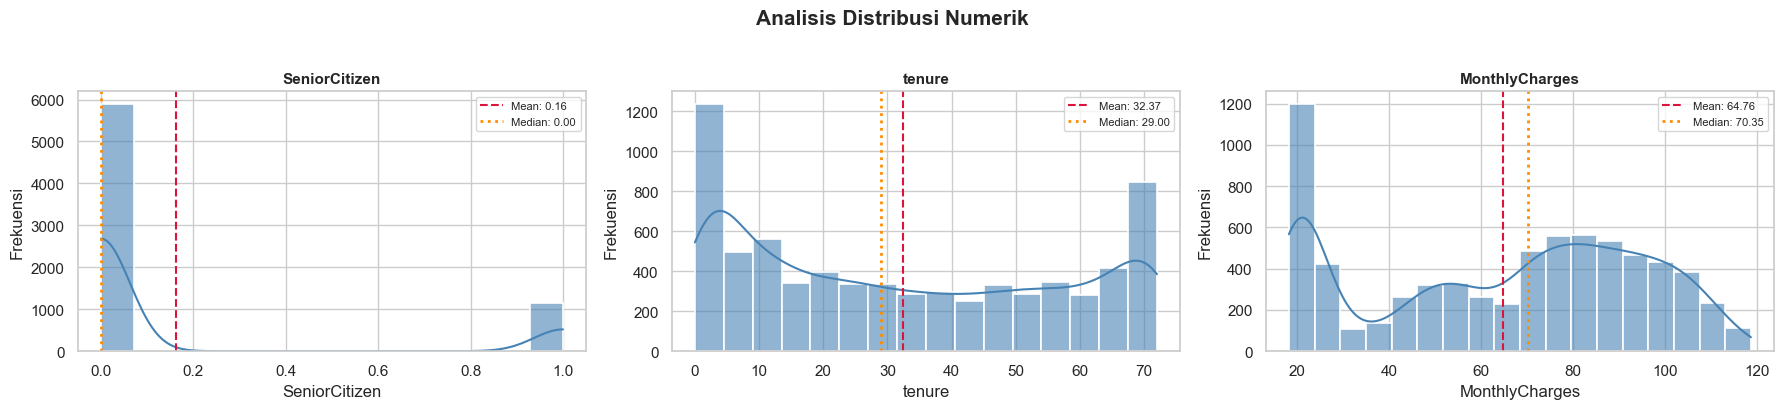

In [8]:
plot_distributions(df, fitur_numeric)

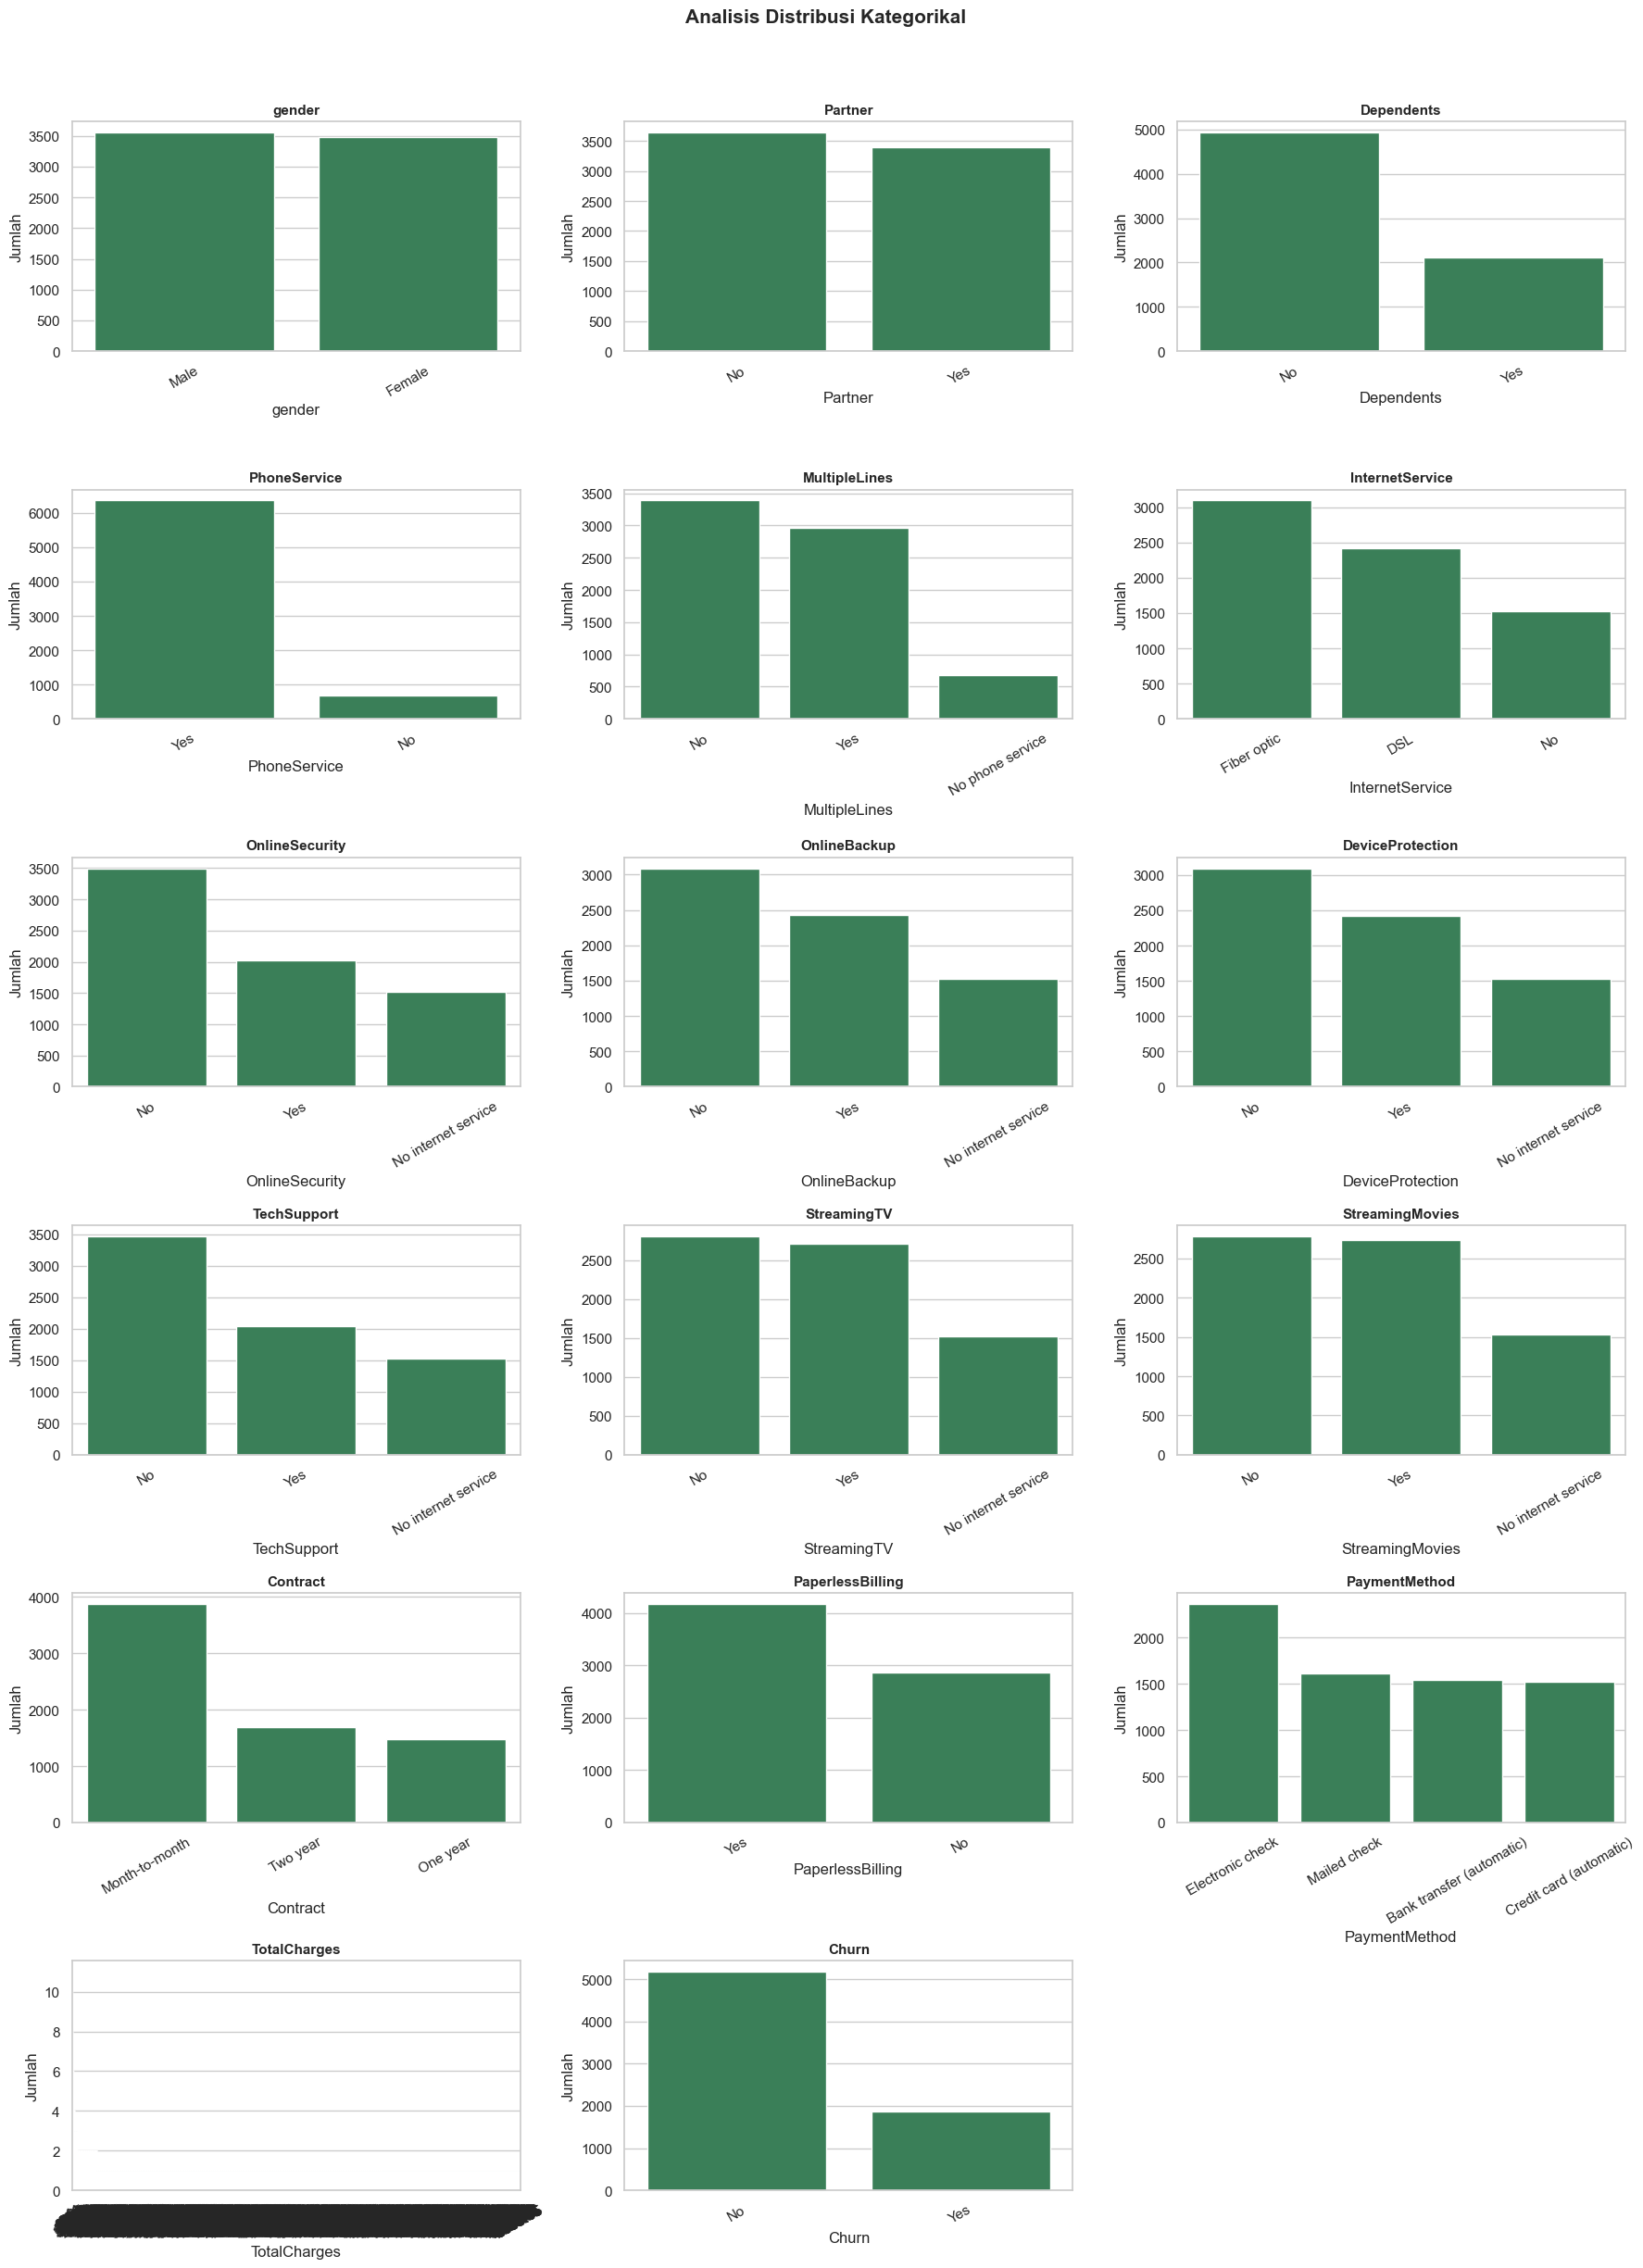

In [9]:
plot_distributions(df, fitur_category)

In [10]:
outlier_report(df)

OUTLIER REPORT  (method=iqr)
       column  n_outliers  pct_outliers  has_outlier  lower_bound  upper_bound
SeniorCitizen        1142         16.21         True          0.0          0.0

Kolom dengan outlier: 1 / 3


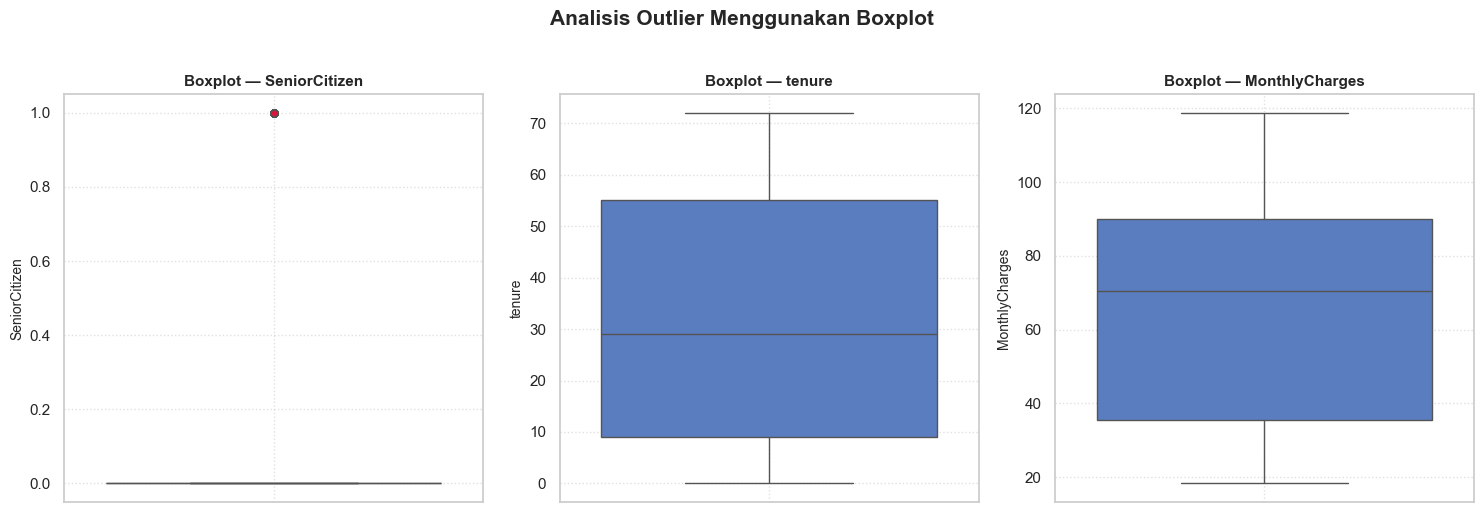

In [11]:
plot_boxplot(df, fitur_numeric)

In [12]:
class_balance(df, 'Churn')

CLASS BALANCE — 'Churn'
       count    pct
Churn              
No      5174  73.46
Yes     1869  26.54

Imbalance ratio (max/min): 2.77x
✓  Dataset relatif balanced.


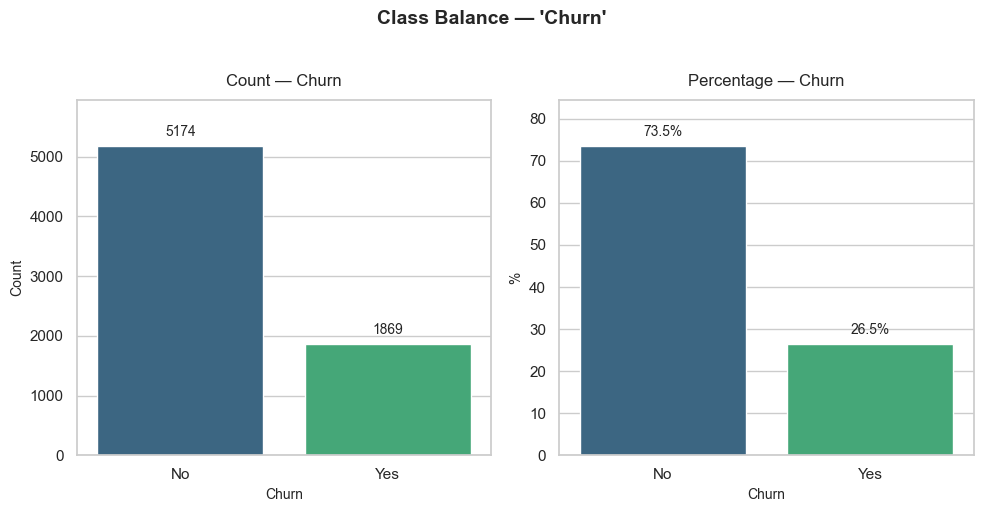

In [13]:
plot_class_balance(df, 'Churn')

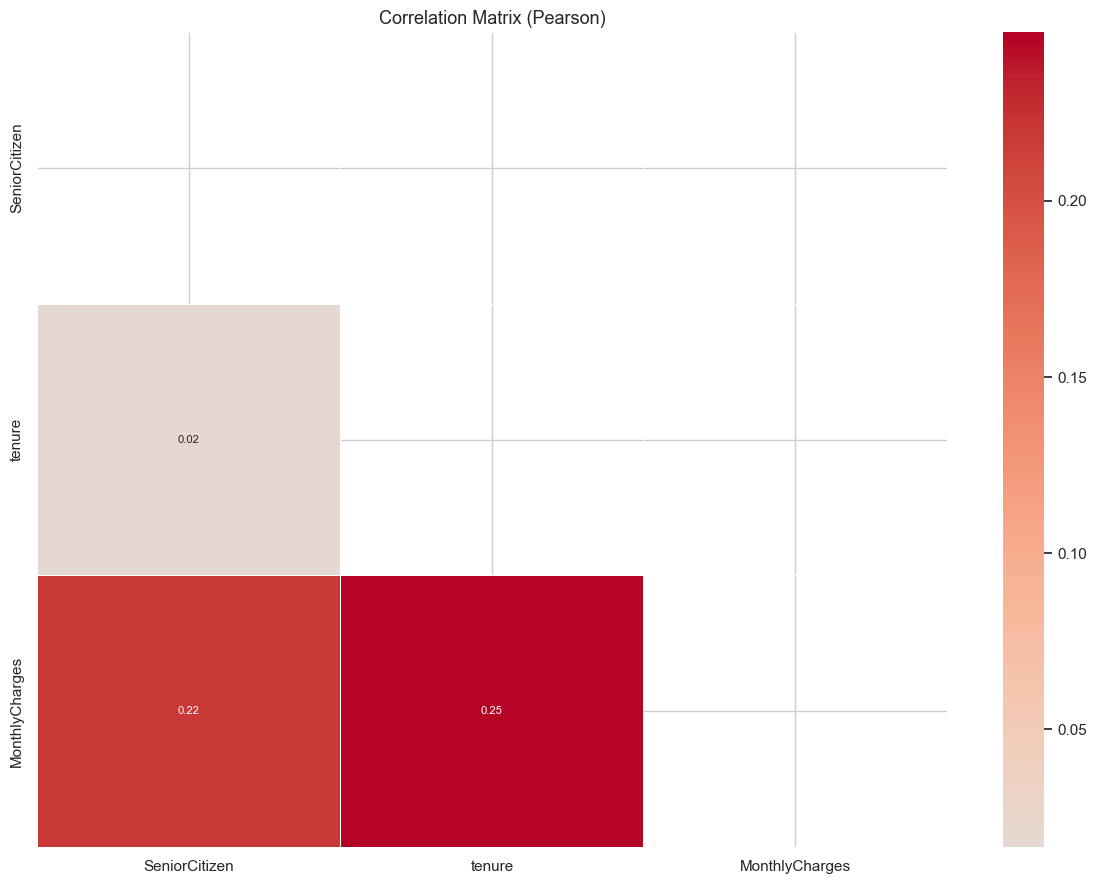

In [14]:
correlation_matrix(df)

## Profil dataset
- Ukuran dataset memiliki 7043 rows × 21 columns
- Dataset tidak mengalami imbalance
- Dataset tidak memiliki missing value sehingga tidak perlu imputer
- Dataset mostly memiliki banyak kategori dibanding dgn numerik, sehingga perlu encoding
- Di sini dataset asli mempunya CustomerID yang bernilai unik setiap customer, ini saya hapus untuk memepercepat visualisasi dan jg CustomerID bisa dihapus saat cleaning dataset

## Fitur yang harus di fix dtype
- TotalCharges terdeteksi `object` padahal numerik

## Strategi encoding label encoding
- ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

## Strategi encoding one hot
- ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract']

── DTYPES ──
                    dtype  nunique            sample
customerID         object     7043        7590-VHVEG
gender             object        2            Female
SeniorCitizen       int64        2                 0
Partner            object        2               Yes
Dependents         object        2                No
tenure              int64       73                 1
PhoneService       object        2                No
MultipleLines      object        3  No phone service
InternetService    object        3               DSL
OnlineSecurity     object        3                No
OnlineBackup       object        3               Yes
DeviceProtection   object        3                No
TechSupport        object        3                No
StreamingTV        object        3                No
StreamingMovies    object        3                No
Contract           object        3    Month-to-month
PaperlessBilling   object        2               Yes
PaymentMethod      object        4  Electronic check
MonthlyCharges    float64     1585             29.85
TotalCharges       object     6531             29.85
Churn              object        2                No